# D10 · Correlated residuals and prewhitening

Consecutive fMRI measurements often share residual fluctuations. When positive autocorrelation aligns with a slow predictor, a sequence of similar residuals can resemble a sustained effect. Treating every scan as independent can underestimate the uncertainty of a contrast. The problem is not fixed by adding more rows from the same correlated process or by reporting that the residual mean is zero.

In this lab, residuals follow a stationary AR(1) covariance with correlation rho to the power of the distance between time points. The marginal variance is one. We know rho=0.7 because we generate the data. This known covariance is an educational advantage that real analysts do not have: actual noise parameters must be estimated and the model checked. AR(1) itself may be inadequate for some acquisition protocols or residual structures.

Prewhitening applies the same linear transform to the outcome and every design column. If V equals L times L-transpose, multiplication by inverse L makes the transformed error covariance the identity. Fitting transformed data and design produces generalized least squares under this known model. Transforming y while leaving X untouched changes the question and generally gives the wrong estimate. Whitening is distinct from temporal high-pass filtering, which removes components rather than simply accounting for their covariance.

We compare an ordinary least-squares estimator with the correct covariance-aware estimator. First calculate the true covariance of OLS analytically: inverse-XTX times X-transpose-V-X times inverse-XTX. Compare it with the covariance that would apply if V were identity. Then simulate repeated datasets to verify the covariance formulas. This separates point estimation from uncertainty: OLS can be unbiased under exogenous fixed predictors even when its usual iid standard error is wrong. The GLS estimator may be more efficient, but no whitening method converts a confounded design into a causal experiment.

Predict whether slow positively correlated noise increases or decreases uncertainty for a slow predictor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
n, rho = 100, .7
X = np.column_stack([np.ones(n),np.sin(np.linspace(0,4*np.pi,n))])
V = linalg.toeplitz(rho**np.arange(n))
L = np.tril(linalg.cholesky(V,lower=True))
assert np.allclose(L @ L.T, V)
Xw = linalg.solve_triangular(L,X,lower=True)
W = linalg.solve_triangular(L,np.eye(n),lower=True)
assert np.allclose(W@V@W.T,np.eye(n))
inv_xtx=np.linalg.inv(X.T@X)
true_ols_cov=inv_xtx@X.T@V@X@inv_xtx
true_gls_cov=np.linalg.inv(Xw.T@Xw)
assert true_ols_cov[1,1] > 3*inv_xtx[1,1]
print('Naive / true OLS / GLS slope SD:',np.sqrt([inv_xtx[1,1],true_ols_cov[1,1],true_gls_cov[1,1]]))

Naive / true OLS / GLS slope SD: [0.14213381 0.31995322 0.31897492]


Repeated synthetic studies validate the covariance, rather than trusting one residual plot.

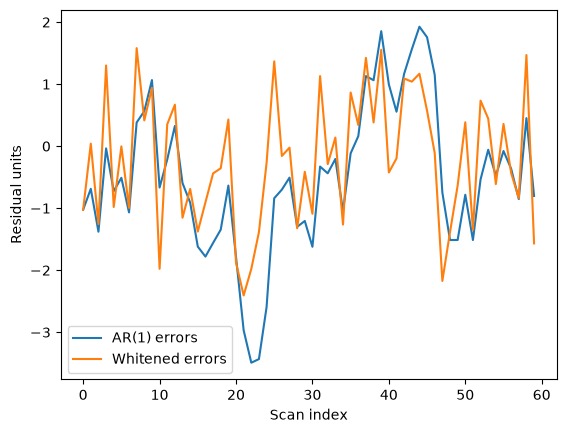

In [2]:
rng=np.random.default_rng(210)
errors=L@rng.normal(size=(n,5000))
y=X@np.array([10.,.5])[:,None]+errors
yw=linalg.solve_triangular(L,y,lower=True)
b_ols=np.linalg.lstsq(X,y,rcond=None)[0]
b_gls=np.linalg.lstsq(Xw,yw,rcond=None)[0]
assert abs(b_gls[1].mean()-.5)<.03
assert np.isclose(b_ols[1].var(ddof=1),true_ols_cov[1,1],rtol=.1)
assert np.isclose(b_gls[1].var(ddof=1),true_gls_cov[1,1],rtol=.1)
whitened=linalg.solve_triangular(L,errors,lower=True)
raw_corr=np.corrcoef(errors[:-1].ravel(),errors[1:].ravel())[0,1]
white_corr=np.corrcoef(whitened[:-1].ravel(),whitened[1:].ravel())[0,1]
assert abs(raw_corr-rho)<.02 and abs(white_corr)<.02
plt.plot(errors[:60,0],label='AR(1) errors');plt.plot(whitened[:60,0],label='Whitened errors')
plt.xlabel('Scan index');plt.ylabel('Residual units');plt.legend();plt.show()

## Supervise the AI, then transfer the idea

**AI prompt:** “Show which transformation acts on both y and X. Explain the difference between unbiased OLS coefficients and incorrect iid uncertainty. Inspect lag-one residual correlation. Do not label an AR(1) toy a validated fMRI prewhitening method.”

**Deliberate mistake:** whiten y only. Compare that fit with the correct transformed-design fit and explain why an intercept no longer remains a plain column of ones after whitening. In real pipelines, record the package covariance model, estimation procedure, filtering, run boundaries, and residual diagnostics. Do not join separate runs as one continuous AR process. A flat residual spectrum or near-zero lag-one correlation alone does not prove all dependence has been removed. Deliver a covariance diagram, a slope-uncertainty comparison, and a statement distinguishing the known-noise classroom model from estimated-noise research inference.

## Answer key — read after your own explanation

WVW-transpose equals identity, and transformed errors have near-zero lag-one correlation. Positive slow residual correlation makes the naive slope uncertainty too small in this design. Simulated coefficient variance agrees with the correct formulas. Both design and outcome must be transformed; one-sided whitening is not GLS. The demonstration knows V exactly; real covariance estimation and misspecification require further checks.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Poldrack DesignEfficiency, generated AR1 noise](https://github.com/poldrack/fmri-analysis-vm/blob/d93fcf8e818c850d0a1b4e96b01ac987f27e9d34/analysis/efficiency/DesignEfficiency.ipynb); [SPM haemodynamic modelling, prewhitening discussion](https://www.fil.ion.ucl.ac.uk/spm/docs/tutorials/beginners/haemodynamic_modelling/). See [the coverage and gaps](../../curriculum/design_coverage.md).